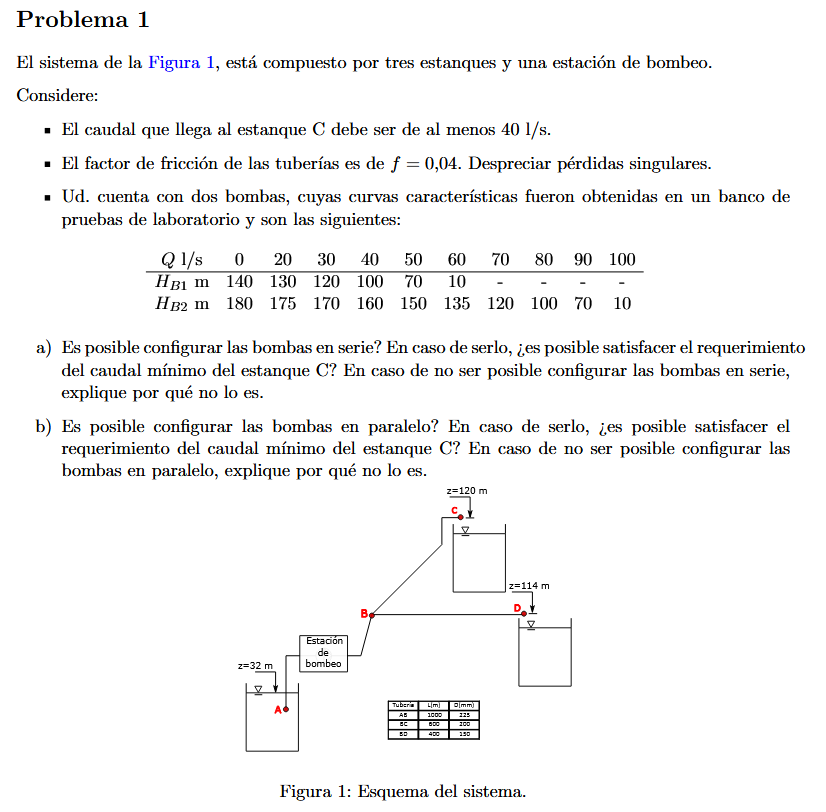

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import fsolve

def derivada_centrada(f, x, i, delta_x):
  x_siguiente = np.array(x, dtype=float)
  x_atras = np.array(x, dtype=float)
  x_siguiente[i] += delta_x
  x_atras[i] -= delta_x

  f_siguiente = f(x_siguiente)
  f_atras = f(x_atras)

  return (f_siguiente - f_atras)/(2*delta_x)

def nr(funcion, H, Q_actual=0.05, delta_x=1e-5):

  tol=1e-4
  max_iter=50
  H_limite = H_max(funcion)

  if H > H_limite:
    return 0

  for i in range(max_iter):

    f = funcion(Q_actual) - H
    df = derivada_centrada(funcion, np.array([Q_actual]), 0, delta_x)
    Q_siguiente = Q_actual - (f / df[0])
    if abs(Q_siguiente - Q_actual) < tol:
      return Q_siguiente
    Q_actual = Q_siguiente

  return Q_actual


In [ ]:
z_A = 32
z_C = 120
z_D = 114
g = 9.81
f = 0.04

k_AB = (8 * f * 1000) / (np.pi**2 * g * 0.225**5)
k_BC = (8 * f * 800) / (np.pi**2 * g * 0.200**5)
k_BD = (8 * f * 400)  / (np.pi**2 * g * 0.150**5)

Q_minimo_C = 0.04

def HB1(Q):
  a = -2.201*(10**7)
  b = 1.761*(10**6)
  c = -68553.459
  d = 364.330638
  e = 139.973045
  return a*(Q**4) + b*(Q**3) + c*(Q**2) + d*Q + e

def HB2(Q):
  a = -6.868*(10**6)
  b = 1.125*(10**6)
  c = -69751.082
  d = 903.624153
  e = 179.5005
  return a*(Q**4) + b*(Q**3) + c*(Q**2) + d*Q + e

def H_max(f):
  Q_busqueda = np.linspace(0, 0.2, 1000)
  H_valores = f(Q_busqueda)
  return np.max(H_valores)


def Serie(Q):
  h1 = HB1(Q)
  h2 = HB2(Q)
  #evitamos sumar las alturas negativas
  return np.maximum(0, h1) + np.maximum(0, h2)

def Paralelo(f1, f2, H_array):
  Q_array = []
  for H in H_array:
    Q_1 = nr(f1, H)
    Q_2 = nr(f2, H)
    Q = Q_1 + Q_2
    Q_array.append(Q)
  return np.array(Q_array)

/tmp/ipython-input-1616144034.py:2: RuntimeWarning: invalid value encountered in sqrt
  Q_BC_array = np.where(H_B_array > z_C, np.sqrt((H_B_array - z_C) / k_BC), 0)


Serie: Q = 67.9 l/s, H = 125.5 m
Paralelo: Q = 75.7 l/s, H = 135.2 m
Q_BC (Serie):    36.6 l/s. NO CUMPLE
Q_BC (Paralelo): 41.6 l/s. CUMPLE


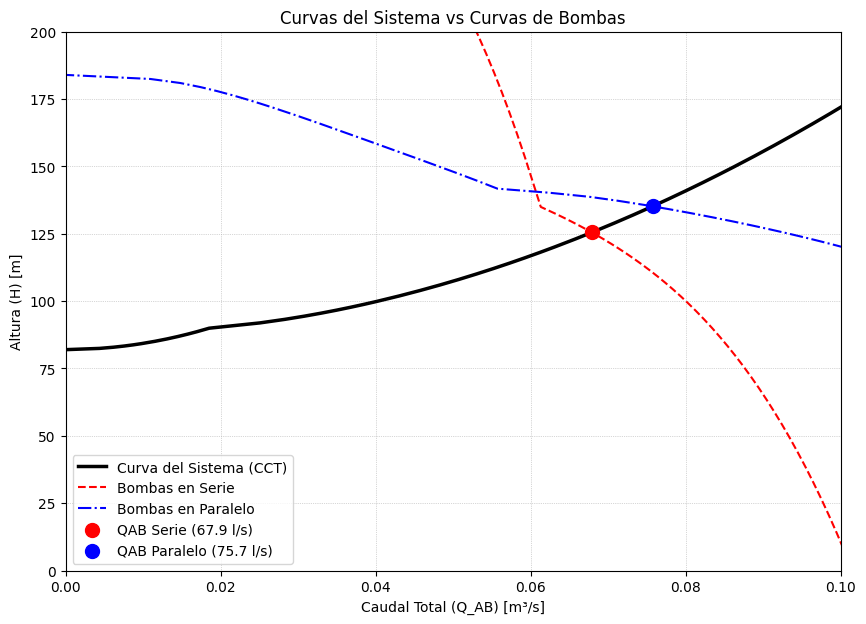

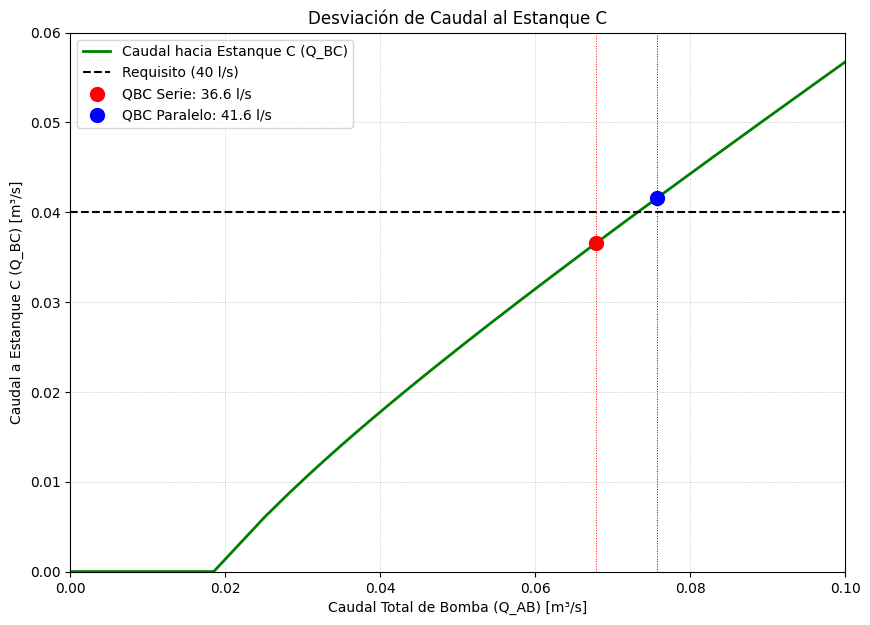

In [ ]:
H_B_array = np.linspace(z_D + 0.001, 180, 200)
Q_BC_array = np.where(H_B_array > z_C, np.sqrt((H_B_array - z_C) / k_BC), 0)
Q_BD_array = np.sqrt((H_B_array - z_D) / k_BD)
Q_AB_array = Q_BC_array + Q_BD_array
H_bomba_array = (H_B_array - z_A) + k_AB * Q_AB_array**2


Q_array = np.linspace(0, 0.2, 200)
H_serie_array = Serie(Q_array)

H_paralelo_array = np.linspace(0.01, 300, 200)
Q_paralelo_array = Paralelo(HB1, HB2, H_paralelo_array)

H_sistema_interpolacion = interp1d(Q_AB_array, H_bomba_array, bounds_error=False, fill_value="extrapolate")

def raiz_serie(Q):
  return Serie(Q) - H_sistema_interpolacion(Q)

Q_op_serie = fsolve(raiz_serie, 0.1)[0]
H_op_serie = Serie(Q_op_serie)

H_paralelo_interpolacion = interp1d(Q_paralelo_array, H_paralelo_array, bounds_error=False, fill_value="extrapolate")

def raiz_paralelo(Q):
  return H_paralelo_interpolacion(Q) - H_sistema_interpolacion(Q)

Q_op_paralelo = fsolve(raiz_paralelo, 0.1)[0]
H_op_paralelo = H_paralelo_interpolacion(Q_op_paralelo)

print(f"Serie: Q = {Q_op_serie*1000:.1f} l/s, H = {H_op_serie:.1f} m")
print(f"Paralelo: Q = {Q_op_paralelo*1000:.1f} l/s, H = {H_op_paralelo:.1f} m")

H_B_op_serie = H_op_serie + z_A - (k_AB * Q_op_serie**2)
Q_BC_op_serie = np.sqrt((H_B_op_serie - z_C) / k_BC)

H_B_op_paralelo = H_op_paralelo + z_A - (k_AB * Q_op_paralelo**2)
Q_BC_op_paralelo = np.sqrt((H_B_op_paralelo - z_C) / k_BC)


print(f"Q_BC (Serie):    {Q_BC_op_serie*1000:.1f} l/s. {'CUMPLE' if Q_BC_op_serie >= Q_minimo_C else 'NO CUMPLE'}")
print(f"Q_BC (Paralelo): {Q_BC_op_paralelo*1000:.1f} l/s. {'CUMPLE' if Q_BC_op_paralelo >= Q_minimo_C else 'NO CUMPLE'}")

#grafico de curvas de bombas y sistema

plt.figure(figsize=(10, 7))
plt.plot(Q_AB_array, H_bomba_array, 'k-', linewidth=2.5, label="Curva del Sistema (CCT)")
plt.plot(Q_array, H_serie_array, 'r--', label="Bombas en Serie")
plt.plot(Q_paralelo_array, H_paralelo_array, 'b-.', label="Bombas en Paralelo")

plt.scatter([Q_op_serie], [H_op_serie], c='r', s=100, zorder=5, label=f"QAB Serie ({Q_op_serie*1000:.1f} l/s)")
plt.scatter([Q_op_paralelo], [H_op_paralelo], c='b', s=100, zorder=5, label=f"QAB Paralelo ({Q_op_paralelo*1000:.1f} l/s)")

plt.title("Curvas del Sistema vs Curvas de Bombas")
plt.xlabel("Caudal Total (Q_AB) [m³/s]")
plt.ylabel("Altura (H) [m]")
plt.legend()
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.xlim(0, 0.1)
plt.ylim(0, 200)
plt.show()

#grafico de desviación de caudal para BC en relación al caudal total

plt.figure(figsize=(10, 7))
plt.plot(Q_AB_array, Q_BC_array, 'g-', linewidth=2, label="Caudal hacia Estanque C (Q_BC)")
plt.axhline(Q_minimo_C, color='k', linestyle='--', label=f"Requisito ({Q_minimo_C*1000:.0f} l/s)")
plt.scatter([Q_op_serie], [Q_BC_op_serie], c='r', s=100, zorder=5, label=f"QBC Serie: {Q_BC_op_serie*1000:.1f} l/s")
plt.scatter([Q_op_paralelo], [Q_BC_op_paralelo], c='b', s=100, zorder=5, label=f"QBC Paralelo: {Q_BC_op_paralelo*1000:.1f} l/s")

plt.axvline(Q_op_serie, color='r', linestyle=':', linewidth=0.7)
plt.axvline(Q_op_paralelo, color='b', linestyle=':', linewidth=0.7)

plt.title("Desviación de Caudal al Estanque C")
plt.xlabel("Caudal Total de Bomba (Q_AB) [m³/s]")
plt.ylabel("Caudal a Estanque C (Q_BC) [m³/s]")
plt.legend()
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.xlim(0, 0.1)
plt.ylim(0, 0.06)
plt.show()

Cotas (Elevaciones):
$$ z_A = 32 \text{ m} $$
$$ z_C = 120 \text{ m} $$
$$ z_D = 114 \text{ m} $$

Tuberías:
Tubería AB: $L = 1000 \text{ m}$, $D = 0.225 \text{ m}$
Tubería BC: $L = 800 \text{ m}$, $D = 0.200 \text{ m}$
Tubería BD: $L = 400 \text{ m}$, $D = 0.150 \text{ m}$

Constantes:
$f = 0.04$
$g = 9.81 \text{ m/s}^2$


La pérdida de carga $h_f$ se calcula como $h_f = k Q^2$. El coeficiente $k$ se obtiene de Darcy-Weisbach:
$$ h_f = f \frac{L}{D} \frac{V^2}{2g} \quad \text{y} \quad V = \frac{Q}{A} = \frac{4Q}{\pi D^2} $$
Sustituyendo $V$:
$$ h_f = f \frac{L}{D} \frac{1}{2g} \left( \frac{4Q}{\pi D^2} \right)^2 = \left( \frac{8fL}{\pi^2 g D^5} \right) Q^2 $$
Por lo tanto, $k = \frac{8fL}{\pi^2 g D^5}$.

Calculamos los $k$ para cada tubería:
$$ k_{AB} = \frac{8 \cdot 0.04 \cdot 1000}{\pi^2 \cdot 9.81 \cdot (0.225)^5} $$
$$ k_{BC} = \frac{8 \cdot 0.04 \cdot 800}{\pi^2 \cdot 9.81 \cdot (0.200)^5} $$
$$ k_{BD} = \frac{8 \cdot 0.04 \cdot 400}{\pi^2 \cdot 9.81 \cdot (0.150)^5} $$

Ecuaciones del Sistema:

Tenemos 4 incógnitas ($Q_{AB}, Q_{BC}, Q_{BD}, H_B$) y 4 ecuaciones.

Ecuación 1:
$$ z_A + H_{\text{bomba}} - hf_{AB} = H_B $$
$$ H_{\text{bomba}} = (H_B - z_A) + k_{AB} \cdot Q_{AB}^2 $$

Ecuación 2:
$$ H_B - hf_{BC} = z_C $$
$$ Q_{BC} = \sqrt{\frac{H_B - z_C}{k_{BC}}} \quad (\text{si } H_B > z_C) $$

Ecuación 3:
$$ H_B - hf_{BD} = z_D $$
$$ Q_{BD} = \sqrt{\frac{H_B - z_D}{k_{BD}}} \quad (\text{si } H_B > z_D) $$

Ecuación 4:
$$ Q_{AB} = Q_{BC} + Q_{BD} $$

Curva del Sistema:

No podemos fijar $Q_{BC} = 0.04$, ya que ese caudal es un resultado y de hacerlo obtendriamos una linea recta, que no se ajusta al aumento de fricción por aumento de caudal. Por lo tanto se creo una CCT usando $H_B$ como una variable a iterar.

Iteramos sobre un rango de valores de $H_B$. Para cada valor de $H_B$ se calcula:

Caudal a C (Ec. 2): $Q_{BC} = \sqrt{\frac{H_B - 120}{k_{BC}}}$ (o 0 si $H_B \le 120$)

Caudal a D (Ec. 3): $Q_{BD} = \sqrt{\frac{H_B - 114}{k_{BD}}}$

Caudal Total (Ec. 4): $Q_{AB} = Q_{BC} + Q_{BD}$

Altura de Bomba (Ec. 1): $H_{\text{bomba}} = (H_B - 32) + k_{AB} \cdot Q_{AB}^2$

Esto nos da los puntos ($Q_{AB}$, $H_{\text{bomba}}$) que forman la CCT.


Buscamos la intersección de la CCT con la curva de la bomba.
$$ H_{\text{bomba}}(Q_{op}) = H_{\text{CCT, demanda}}(Q_{op}) $$

Una vez que encontramos el punto de operación ($Q_{op}, H_{op}$):

Calculamos la $H_B$ real en la union: $H_{B,op} = z_A + H_{op} - k_{AB} \cdot Q_{op}^2$

Con ese $H_{B,op}$, calculamos el $Q_{BC}$ real: $Q_{BC,op} = \sqrt{\frac{H_{B,op} - z_C}{k_{BC}}}$

Comprobamos si $Q_{BC,op} \ge 0.04 \text{ m}^3/\text{s}$.

**Respuesta a las preguntas:**

En este caso, solo la configuración en paralelo logró entregar la demanda de $0.04 \text{ m}^3/\text{s}$ para la tubería BC.

La razón por la que en serie no logró el caudal mínimo de la tubería BC, se debe a que el funcionamiento del sistema para la configuración en serie equilibrá los caudales de tal manera que las perdidas generen la misma energía en la unión del punto B. En este caso, las cotas y perdidas friccionales junto a sus constantes como el largo y el diametro, establecieron un sistema cuyo equilibrio es menor al caudal mínimo para BC. Se podría decir que el sistema, al igual que tiene una CCT propia, tambien posee una proporción específica de desviación de caudales para un caudal total entrante que es propio de las configuración de las perdidas y cotas.

Por otro lado, el sistema en paralelo si lo logró porque la intersección de esta configuración se consiguio en un punto donde el caudal de entrada es mayor y la proporción de desviación de caudales otorgo unos valores que permitieron la entrada de un caudal BC mayor al mínimo establecido.